# Frame extract

In [1]:
import os
import cv2


video_base_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Train1"
output_base_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Processed_Frames_Original1"


os.makedirs(output_base_path, exist_ok=True)

IMG_SIZE = (224, 224)  


for class_name in os.listdir(video_base_path):
    class_folder = os.path.join(video_base_path, class_name)
    if not os.path.isdir(class_folder):
        continue

    print(f"\n Processing Class: {class_name}")

    # Create class folder in output
    output_class_folder = os.path.join(output_base_path, class_name)
    os.makedirs(output_class_folder, exist_ok=True)

    for video_file in os.listdir(class_folder):
        if not video_file.endswith((".mp4", ".avi", ".mov")):
            continueS

        video_path = os.path.join(class_folder, video_file)
        video_name = os.path.splitext(video_file)[0]

        
        video_output_folder = os.path.join(output_class_folder, video_name)
        os.makedirs(video_output_folder, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_count = 0

        print(f" Extracting frames from: {video_file}")

        while True:
            ret, frame = cap.read()
            if not ret:
                break

  
            frame = cv2.resize(frame, IMG_SIZE)

      
            frame_save_path = os.path.join(video_output_folder, f"frame_{frame_count:04d}.png")
            cv2.imwrite(frame_save_path, frame)
            frame_count += 1

        cap.release()
        print(f" Saved {frame_count} frames → {video_output_folder}")

print("\n All videos processed successfully! Frames saved inside their own folders (ORIGINAL frames, no background removal) ")



 Processing Class: Beautiful
 Extracting frames from: Beautiful_1.mp4
 Saved 149 frames → C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Processed_Frames_Original1\Beautiful\Beautiful_1
 Extracting frames from: Beautiful_10.mp4
 Saved 104 frames → C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Processed_Frames_Original1\Beautiful\Beautiful_10
 Extracting frames from: Beautiful_11.mp4


KeyboardInterrupt: 

# Feature extractation using the ResNet18

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image


base_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Processed_Frames_Original1"
output_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original"

os.makedirs(output_path, exist_ok=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Using device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet = nn.Sequential(*list(resnet.children())[:-1])  
resnet.eval().to(device)


def extract_features_sequence(video_folder):
    frame_features = []

    for frame_file in sorted(os.listdir(video_folder)):
        if not frame_file.endswith(".png"):
            continue

        frame_path = os.path.join(video_folder, frame_file)
        img = Image.open(frame_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)#[1,3,224,244]

        with torch.no_grad():
            feature = resnet(img_tensor).squeeze().cpu()  # [512]
            frame_features.append(feature)

    if len(frame_features) == 0:
        return None

    
    return torch.stack(frame_features)#[number of frame,512]


for class_name in os.listdir(base_path):
    class_folder = os.path.join(base_path, class_name)
    if not os.path.isdir(class_folder):
        continue

    print(f"\n Processing Class: {class_name}")

    for video_folder in os.listdir(class_folder):
        video_path = os.path.join(class_folder, video_folder)
        if not os.path.isdir(video_path):
            continue

        print(f" Extracting sequential features from: {video_folder}")
        video_features = extract_features_sequence(video_path)

        if video_features is not None:
            save_path = os.path.join(output_path, f"{video_folder}.pt")
            torch.save({
                "features": video_features,  # shape: [num_frames, 512]
                "class": class_name
            }, save_path)
            print(f" Saved sequential features → {save_path}")

print("\n Sequential feature extraction complete!")


In [6]:
import cv2

video_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Train1\Beautiful\Beautiful_1.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

duration = total_frames / fps if fps > 0 else 0

print("FPS:", fps)
print("Total Frames:", total_frames)
print("Duration (sec):", duration)

cap.release()


FPS: 29.72634472362923
Total Frames: 149.0
Duration (sec): 5.012388888888889


# Traning BilSTM

 Using device: cpu
 Loaded 89 videos from 6 classes
Classes: ['Beautiful_(Sign_2)', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']
Epoch [1/50] - Loss: 2.0263 - Accuracy: 16.85%
Epoch [2/50] - Loss: 1.8506 - Accuracy: 11.24%
Epoch [3/50] - Loss: 1.8218 - Accuracy: 16.85%
Epoch [4/50] - Loss: 1.7840 - Accuracy: 16.85%
Epoch [5/50] - Loss: 1.7870 - Accuracy: 20.22%
Epoch [6/50] - Loss: 1.7933 - Accuracy: 19.10%
Epoch [7/50] - Loss: 1.7288 - Accuracy: 29.21%
Epoch [8/50] - Loss: 1.7473 - Accuracy: 20.22%
Epoch [9/50] - Loss: 1.7648 - Accuracy: 19.10%
Epoch [10/50] - Loss: 1.7569 - Accuracy: 23.60%
Epoch [11/50] - Loss: 1.7000 - Accuracy: 33.71%
Epoch [12/50] - Loss: 1.7095 - Accuracy: 26.97%
Epoch [13/50] - Loss: 1.6625 - Accuracy: 29.21%
Epoch [14/50] - Loss: 1.6696 - Accuracy: 31.46%
Epoch [15/50] - Loss: 1.6554 - Accuracy: 33.71%
Epoch [16/50] - Loss: 1.6651 - Accuracy: 31.46%
Epoch [17/50] - Loss: 1.6357 - Accuracy: 30.34%
Epoch [18/50] - Loss: 1.6928 - Accuracy: 29.21%
Epoc

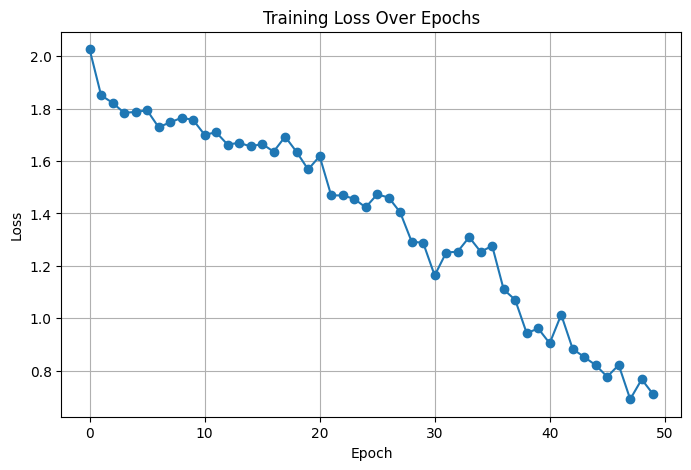

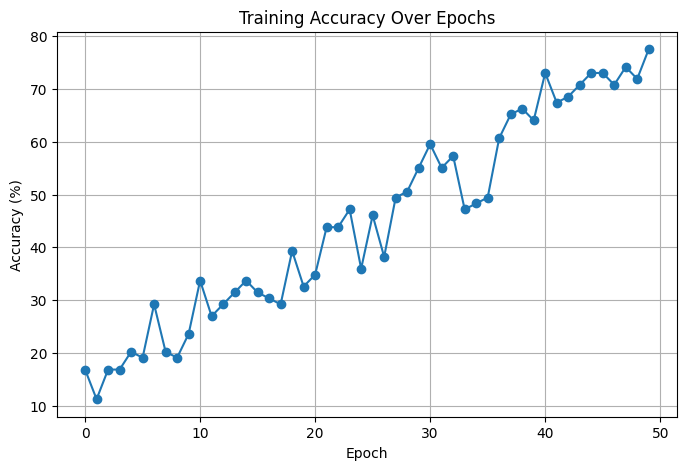

In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt



features_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original"
model_save_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_model_bilstm_sequence_original1.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Using device:", device)

class GestureSequenceDataset(Dataset):
    def __init__(self, feature_folder):
        self.samples = []
        for file in os.listdir(feature_folder):
            if file.endswith(".pt"):
                data = torch.load(os.path.join(feature_folder, file))
                self.samples.append((data["features"], data["class"]))
        self.class_names = sorted(list(set(c for _, c in self.samples)))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.class_names)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, cls_name = self.samples[idx]
        label = self.class_to_idx[cls_name]
        return seq, label


def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True)
    return padded, torch.tensor(labels), lengths


dataset = GestureSequenceDataset(features_path)
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

print(f" Loaded {len(dataset)} videos from {len(dataset.class_names)} classes")
print("Classes:", dataset.class_names)


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, num_layers=1, num_classes=len(dataset.class_names)):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)
        last_outputs = out[range(len(out)), lengths - 1, :]
        out = self.dropout(last_outputs)
        return self.fc(out)


model = BiLSTMModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)



loss_history = []
acc_history = []

EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for seqs, labels, lengths in loader:
        seqs, labels, lengths = seqs.to(device), labels.to(device), lengths.to(device)

        optimizer.zero_grad()
        outputs = model(seqs, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / len(loader)
    epoch_acc = 100 * correct / total

    
    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")


torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": dataset.class_names
}, model_save_path)

print("\n Training complete!")
print(" Model saved at:", model_save_path)
print(" Classes:", dataset.class_names)



plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(acc_history, marker='o')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


# Prediction on TestData 

In [4]:
import os
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np


test_video_folder = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Test"
model_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_model_bilstm_sequence_original1.pth"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


checkpoint = torch.load(model_path, map_location=device)
class_names = checkpoint["class_names"]


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, num_layers=1, num_classes=len(class_names)):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        last_outputs = out[range(len(out)), lengths - 1, :]
        out = self.dropout(last_outputs)
        return self.fc(out)


model = BiLSTMModel().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(" Model Loaded Successfully\n")


resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.eval().to(device)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


def extract_video_features(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_features = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (224, 224))

  
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        img_tensor = transform(img).unsqueeze(0).to(device)

     
        with torch.no_grad():
            feat = resnet(img_tensor).squeeze().cpu()  # [512]
            frame_features.append(feat)

    cap.release()
    if len(frame_features) == 0:
        return None
    return torch.stack(frame_features)  # [seq_len, 512]


def predict_video(video_path):
    features = extract_video_features(video_path)
    if features is None:
        return " No frames found", 0.0

    lengths = torch.tensor([len(features)], dtype=torch.long)#Lstm need actual lenght
    features = features.unsqueeze(0).to(device)  # [1, seq_len, 512]

    with torch.no_grad():
        outputs = model(features, lengths)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item() * 100

    return class_names[pred_idx], confidence

print(" Starting predictions...\n")
for video_file in os.listdir(test_video_folder):
    if not video_file.endswith((".mp4", ".avi", ".mov")):
        continue

    video_path = os.path.join(test_video_folder, video_file)
    pred, conf = predict_video(video_path)
    print(f" {video_file} → Predicted: {pred} | Confidence: {conf:.2f}%")

print("\n All predictions complete!")


🧠 Using device: cpu
 Model Loaded Successfully

 Starting predictions...

 Person10_Beautiful.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 88.31%
 Person10_Good_Morning.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 69.28%
 Person10_Headache.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 75.36%
 Person10_Hello.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 61.93%
 Person10_Namaste.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 84.38%
 Person1_Beautiful.mp4 → Predicted: Headache | Confidence: 45.06%
 Person1_Good_Morning.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 64.28%
 Person1_Happy.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 54.60%
 Person1_Headache.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 46.77%
 Person1_Hello.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 71.99%
 Person1_Namaste.mp4 → Predicted: Beautiful_(Sign_2) | Confidence: 50.86%
 Person2_Beautiful.mp4 → Predicted: Happy | Confidence: 81.42%
 Person2_Good_Morning.mp4 → Predicted: Happy

KeyboardInterrupt: 

In [3]:
import os
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report


# ================= PATHS =================
test_video_folder = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Test"
model_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_model_bilstm_sequence_original1.pth"


# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧠 Using device:", device)


# ================= LOAD MODEL =================
checkpoint = torch.load(model_path, map_location=device)
class_names = checkpoint["class_names"]


class BiLSTMModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, num_layers=1, num_classes=len(class_names)):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        last_outputs = out[range(len(out)), lengths - 1, :]
        out = self.dropout(last_outputs)
        return self.fc(out)


model = BiLSTMModel().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("✅ Model Loaded Successfully\n")


# ================= RESNET18 =================
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.eval().to(device)


# ================= TRANSFORMS =================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ================= FEATURE EXTRACTION =================
def extract_video_features(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_features = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (224, 224))
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = resnet(img_tensor).squeeze().cpu()  # [512]
            frame_features.append(feat)

    cap.release()

    if len(frame_features) == 0:
        return None

    return torch.stack(frame_features)  # [seq_len, 512]


# ================= PREDICTION =================
def predict_video(video_path):
    features = extract_video_features(video_path)

    if features is None:
        return "No frames", 0.0

    lengths = torch.tensor([len(features)], dtype=torch.long)
    features = features.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(features, lengths)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item() * 100

    return class_names[pred_idx], confidence


# ================= TEST LOOP =================
y_true = []
y_pred = []

print("🚀 Starting predictions...\n")

for true_class in os.listdir(test_video_folder):
    class_path = os.path.join(test_video_folder, true_class)

    if not os.path.isdir(class_path):
        continue

    for video_file in os.listdir(class_path):
        if not video_file.endswith((".mp4", ".avi", ".mov")):
            continue

        video_path = os.path.join(class_path, video_file)
        pred, conf = predict_video(video_path)

        y_true.append(true_class)
        y_pred.append(pred)

        print(f"{video_file} → True: {true_class} | Predicted: {pred} | Confidence: {conf:.2f}%")

print("\n✅ All predictions complete!")


# ================= CLASSIFICATION REPORT =================
print("\n📊 Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=class_names,
        target_names=class_names,
        digits=4
    )
)


🧠 Using device: cpu
✅ Model Loaded Successfully

🚀 Starting predictions...


✅ All predictions complete!

📊 Classification Report:

                    precision    recall  f1-score   support

Beautiful_(Sign_2)     0.0000    0.0000    0.0000       0.0
      Good_Morning     0.0000    0.0000    0.0000       0.0
             Happy     0.0000    0.0000    0.0000       0.0
          Headache     0.0000    0.0000    0.0000       0.0
             Hello     0.0000    0.0000    0.0000       0.0
           Namaste     0.0000    0.0000    0.0000       0.0

          accuracy                         0.0000       0.0
         macro avg     0.0000    0.0000    0.0000       0.0
      weighted avg     0.0000    0.0000    0.0000       0.0



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:15

# Lstm

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence


features_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Sequential_Features_Original"
model_save_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_model_lstm_sequence_original1.pth"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ===================== DATASET =====================
class GestureSequenceDataset(Dataset):
    def __init__(self, feature_folder):
        self.samples = []
        for file in os.listdir(feature_folder):
            if file.endswith(".pt"):
                data = torch.load(os.path.join(feature_folder, file))
                self.samples.append((data["features"], data["class"]))

        self.class_names = sorted(list(set(c for _, c in self.samples)))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.class_names)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, cls_name = self.samples[idx]
        label = self.class_to_idx[cls_name]
        return seq, label


def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True)  # [B, max_len, 512]
    return padded, torch.tensor(labels), lengths


dataset = GestureSequenceDataset(features_path)
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

print(f"Loaded {len(dataset)} videos from {len(dataset.class_names)} classes")
print("Classes:", dataset.class_names)


# ===================== LSTM MODEL =====================
class LSTMModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, num_layers=1, num_classes=len(dataset.class_names)):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=False)  # Uni-directional LSTM
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)

        last_outputs = out[range(len(out)), lengths - 1, :]
        out = self.dropout(last_outputs)
        return self.fc(out)


model = LSTMModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


# ===================== TRAINING LOOP =====================
EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for seqs, labels, lengths in loader:
        seqs, labels, lengths = seqs.to(device), labels.to(device), lengths.to(device)

        optimizer.zero_grad()
        outputs = model(seqs, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {total_loss/len(loader):.4f} - Accuracy: {acc:.2f}%")


# ===================== SAVE MODEL =====================
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": dataset.class_names
}, model_save_path)

print("\nTraining complete!")
print("Model saved at:", model_save_path)
print("Classes:", dataset.class_names)


In [ ]:
import os
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np


test_video_folder = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Test"
model_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\sign_model_lstm_sequence_original1.pth"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧠 Using device:", device)


checkpoint = torch.load(model_path, map_location=device)
class_names = checkpoint["class_names"]


# --------------------- LSTM Model ---------------------
class LSTMModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, num_layers=1, num_classes=len(class_names)):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=False)  # Uni-directional LSTM
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        last_outputs = out[range(len(out)), lengths - 1, :]
        out = self.dropout(last_outputs)
        return self.fc(out)


model = LSTMModel().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(" Model Loaded Successfully\n")


# ---------- Frame Feature Extractor (ResNet18) ----------
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.eval().to(device)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


def extract_video_features(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_features = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (224, 224))
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = resnet(img_tensor).squeeze().cpu()  # [512]
            frame_features.append(feat)

    cap.release()
    if len(frame_features) == 0:
        return None

    return torch.stack(frame_features)  # [seq_len, 512]


def predict_video(video_path):
    features = extract_video_features(video_path)
    if features is None:
        return "❌ No frames found", 0.0

    lengths = torch.tensor([len(features)], dtype=torch.long)
    features = features.unsqueeze(0).to(device)  # [1, seq_len, 512]

    with torch.no_grad():
        outputs = model(features, lengths)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item() * 100

    return class_names[pred_idx], confidence


# --------------------- Start Prediction ---------------------
print("🔍 Starting predictions...\n")
for video_file in os.listdir(test_video_folder):
    if not video_file.endswith((".mp4", ".avi", ".mov")):
        continue

    video_path = os.path.join(test_video_folder, video_file)
    pred, conf = predict_video(video_path)
    print(f" 🎬 {video_file} → Predicted: {pred} | Confidence: {conf:.2f}%")

print("\n✅ All predictions complete!")
